# Avaliação e métricas — câncer de mama (maligno vs benigno)

Avaliação dos modelos no **conjunto de teste** e escolha do melhor pelo contexto clínico.

- **Entrada:** `src/db/outputs/breast-cancer-wisconsin-data/04-modelagem-treino/artifacts/modelos_treinados.joblib` (notebook 04)
- **Alvo:** 1 = maligno, 0 = benigno
- **Métricas:** accuracy, recall de maligno, F1 de maligno
- **Saídas:** `src/db/outputs/breast-cancer-wisconsin-data/05-avaliacao-metricas/metrics/metricas_teste.json` e figuras em `figures/`
- **Próximo:** explicabilidade no notebook 06

## 1 - Setup e carregar artefato do notebook 04

In [1]:
# Célula comum (v2) + imports de avaliação
from pathlib import Path
import json
import re

import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)

# Encontra a raiz do repositório (notebooks em subpastas ou na raiz)
def encontrar_raiz() -> Path:
    atual = Path.cwd().resolve()
    for candidato in [atual, *atual.parents]:
        if (candidato / "src" / "db").is_dir():
            return candidato
    raise FileNotFoundError("Raiz do repositório não encontrada.")

RAIZ = encontrar_raiz()
OUTPUT_BASE = RAIZ / "src/db/outputs/breast-cancer-wisconsin-data"

PASTA_ENTRADA = OUTPUT_BASE / "04-modelagem-treino"
PASTA_BASE = OUTPUT_BASE / "05-avaliacao-metricas"
PASTA_FIGURAS = PASTA_BASE / "figures"
PASTA_METRICAS = PASTA_BASE / "metrics"
PASTA_ARTEFATOS = PASTA_BASE / "artifacts"
CAMINHO_ARTEFATO_04 = PASTA_ENTRADA / "artifacts" / "modelos_treinados.joblib"

for pasta in (PASTA_FIGURAS, PASTA_METRICAS, PASTA_ARTEFATOS):
    pasta.mkdir(parents=True, exist_ok=True)

In [2]:
# Carrega modelos + holdout — sem retreinar
if not CAMINHO_ARTEFATO_04.exists():
    raise FileNotFoundError("Execute o notebook 04 primeiro.")

pacote = joblib.load(CAMINHO_ARTEFATO_04)
modelos_treinados = pacote["modelos_treinados"]
atributos_teste = pacote["atributos_teste"]
rotulo_teste = pacote["rotulo_teste"]
colunas_atributos = pacote["colunas_atributos"]

print(f"Artefato 04: {CAMINHO_ARTEFATO_04}")
print(f"Modelos: {list(modelos_treinados.keys())}")
print(f"Teste: {len(atributos_teste)} amostras | Atributos: {len(colunas_atributos)}")

Artefato 04: E:\_git\fiap\fase1\tech-challenge-fase1\src\db\outputs\breast-cancer-wisconsin-data\04-modelagem-treino\artifacts\modelos_treinados.joblib
Modelos: ['Regressão Logística', 'Árvore de Decisão', 'SVM', 'Gradient Boosting', 'Random Forest']
Teste: 114 amostras | Atributos: 30


## 2 - Métricas por modelo (conjunto de teste)

Cada pipeline é avaliado **apenas no teste**. Salvamos accuracy, recall e F1 da classe maligno (rótulo `1`), além da matriz de confusão.

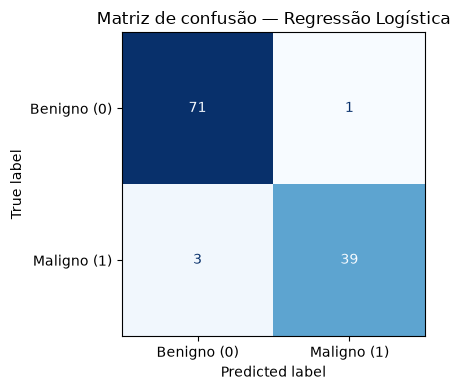

Regressão Logística
  acurácia=0.9649 | recall_maligno=0.9286 | f1_maligno=0.9512
  figura: matriz_confusao_regressao_logistica.png



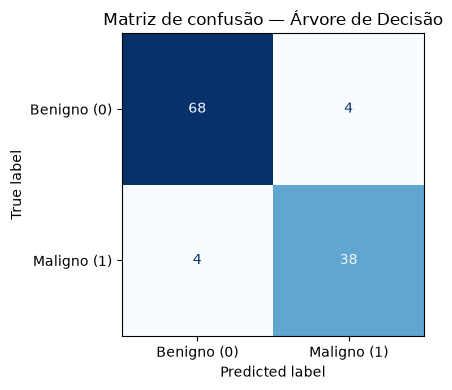

Árvore de Decisão
  acurácia=0.9298 | recall_maligno=0.9048 | f1_maligno=0.9048
  figura: matriz_confusao_arvore_de_decisao.png



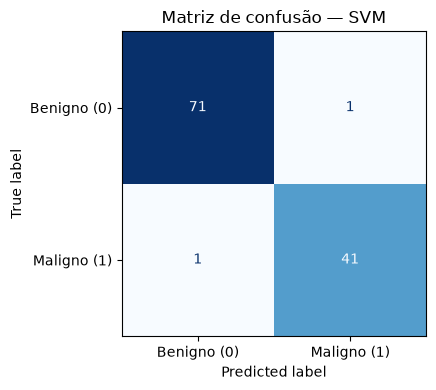

SVM
  acurácia=0.9825 | recall_maligno=0.9762 | f1_maligno=0.9762
  figura: matriz_confusao_svm.png



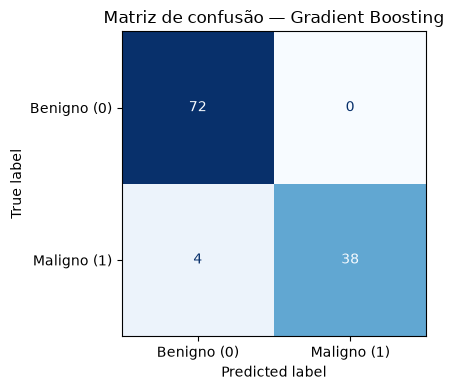

Gradient Boosting
  acurácia=0.9649 | recall_maligno=0.9048 | f1_maligno=0.9500
  figura: matriz_confusao_gradient_boosting.png



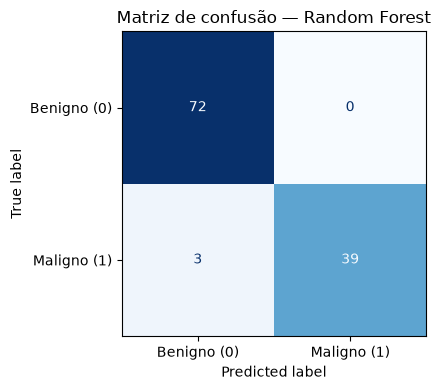

Random Forest
  acurácia=0.9737 | recall_maligno=0.9286 | f1_maligno=0.9630
  figura: matriz_confusao_random_forest.png



In [3]:
def slugify(nome: str) -> str:
    # Nome de arquivo estável a partir do rótulo do modelo (sem acentos)
    mapa = str.maketrans(
        "áàãâäéèêëíìîïóòõôöúùûüçñÁÀÃÂÄÉÈÊËÍÌÎÏÓÒÕÔÖÚÙÛÜÇÑ",
        "aaaaaeeeeiiiiooooouuuucnAAAAAEEEEIIIIOOOOOUUUUCN",
    )
    texto = nome.translate(mapa).lower()
    texto = re.sub(r"[^a-z0-9]+", "_", texto)
    return texto.strip("_")


resultados = {}
caminhos_matrizes = {}

for nome, pipeline in modelos_treinados.items():
    rotulo_previsto = pipeline.predict(atributos_teste)
    relatorio = classification_report(
        rotulo_teste, rotulo_previsto, output_dict=True, zero_division=0
    )
    resultados[nome] = {
        "acuracia": relatorio["accuracy"],
        "recall_maligno": relatorio["1"]["recall"],
        "f1_maligno": relatorio["1"]["f1-score"],
        "precisao_maligno": relatorio["1"]["precision"],
    }

    matriz = confusion_matrix(rotulo_teste, rotulo_previsto)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=["Benigno (0)", "Maligno (1)"],
    ).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Matriz de confusão — {nome}")
    fig.tight_layout()

    caminho_fig = PASTA_FIGURAS / f"matriz_confusao_{slugify(nome)}.png"
    fig.savefig(caminho_fig, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    caminhos_matrizes[nome] = str(caminho_fig)
    print(f"{nome}")
    print(
        f"  acurácia={resultados[nome]['acuracia']:.4f} | "
        f"recall_maligno={resultados[nome]['recall_maligno']:.4f} | "
        f"f1_maligno={resultados[nome]['f1_maligno']:.4f}"
    )
    print(f"  figura: {caminho_fig.name}\n")

## 3 - Escolher melhor modelo

Critério: **maior recall de maligno**. Em triagem clínica, priorizar detectar malignos reduz **falsos negativos** (tumor maligno classificado como benigno).

In [4]:
nome_melhor = max(resultados, key=lambda n: resultados[n]["recall_maligno"])
melhor_pipeline = modelos_treinados[nome_melhor]
metricas_melhor = resultados[nome_melhor]

print(f"Melhor modelo (por recall de maligno): {nome_melhor}")
print(
    f"  acurácia={metricas_melhor['acuracia']:.4f} | "
    f"recall_maligno={metricas_melhor['recall_maligno']:.4f} | "
    f"f1_maligno={metricas_melhor['f1_maligno']:.4f}"
)

Melhor modelo (por recall de maligno): SVM
  acurácia=0.9825 | recall_maligno=0.9762 | f1_maligno=0.9762


## 4 - Salvar métricas (JSON) e atualizar artefato

In [5]:
resultados_saida = {**resultados, "_melhor_modelo": nome_melhor}

caminho_metricas = PASTA_METRICAS / "metricas_teste.json"
with open(caminho_metricas, "w", encoding="utf-8") as f:
    json.dump(resultados_saida, f, indent=2, ensure_ascii=False)

# Opcional: incluir o nome do melhor modelo no joblib para o notebook 06
pacote_atualizado = {
    **pacote,
    "nome_melhor_modelo": nome_melhor,
}
caminho_artefato = PASTA_ARTEFATOS / "modelos_treinados.joblib"
joblib.dump(pacote_atualizado, caminho_artefato)

print("Métricas salvas:", caminho_metricas)
print("Artefato atualizado:", caminho_artefato)
print("Melhor modelo:", nome_melhor)

Métricas salvas: E:\_git\fiap\fase1\tech-challenge-fase1\src\db\outputs\breast-cancer-wisconsin-data\05-avaliacao-metricas\metrics\metricas_teste.json
Artefato atualizado: E:\_git\fiap\fase1\tech-challenge-fase1\src\db\outputs\breast-cancer-wisconsin-data\05-avaliacao-metricas\artifacts\modelos_treinados.joblib
Melhor modelo: SVM


## 5 - Discussão da métrica

### Recall vs acurácia vs F1

| Métrica | O que mede | Limitação neste problema |
|---------|------------|--------------------------|
| **Acurácia** | Proporção de acertos totais | Pode parecer alta mesmo com falhas na classe maligna, especialmente se houver mais casos benignos |
| **Recall (maligno)** | Fração de tumores malignos corretamente detectados | Pode aumentar falsos positivos (benigno marcado como maligno) |
| **F1 (maligno)** | Equilíbrio entre precisão e recall da classe maligna | Útil como resumo, mas não prioriza sozinho a redução de falsos negativos |

### Por que recall de maligno é prioritário

Neste contexto de **triagem**, o custo de um **falso negativo** (maligno classificado como benigno) é clínico e potencialmente grave: o paciente pode deixar de receber investigação adicional a tempo.

Um **falso positivo** (benigno classificado como maligno) gera custo e ansiedade, mas em geral leva a exames complementares — um erro mais recuperável do que deixar passar um maligno.

Por isso o notebook escolhe o modelo com **maior recall de maligno**. A acurácia e o F1 continuam reportados para transparência e comparação, mas não são o critério de seleção.

> O modelo apoia a decisão; **não substitui** o diagnóstico médico.

## 6 - Validação

In [6]:
assert (PASTA_METRICAS / "metricas_teste.json").exists()
assert len(caminhos_matrizes) >= 2
for caminho in caminhos_matrizes.values():
    assert Path(caminho).exists()

with open(PASTA_METRICAS / "metricas_teste.json", encoding="utf-8") as f:
    metricas_lidas = json.load(f)

assert "_melhor_modelo" in metricas_lidas
assert metricas_lidas["_melhor_modelo"] == nome_melhor
assert nome_melhor in metricas_lidas
assert set(metricas_lidas[nome_melhor].keys()) >= {
    "acuracia",
    "recall_maligno",
    "f1_maligno",
}

print("Validação OK")
print("Melhor modelo:", metricas_lidas["_melhor_modelo"])
print("JSON:", PASTA_METRICAS / "metricas_teste.json")
print("Figuras:", [Path(c).name for c in caminhos_matrizes.values()])

Validação OK
Melhor modelo: SVM
JSON: E:\_git\fiap\fase1\tech-challenge-fase1\src\db\outputs\breast-cancer-wisconsin-data\05-avaliacao-metricas\metrics\metricas_teste.json
Figuras: ['matriz_confusao_regressao_logistica.png', 'matriz_confusao_arvore_de_decisao.png', 'matriz_confusao_svm.png', 'matriz_confusao_gradient_boosting.png', 'matriz_confusao_random_forest.png']
